# MultiOutputKriging on a curve-valued simulator (Octave)

A simulator often returns a **curve** per run rather than a single number. Here each run returns the damped
oscillation

$$y(x, t) = e^{-a(x)\,t} \cos\!\left(\frac{2\pi f(x)\, t}{5}\right),\qquad f = 0.5 + x_1,\quad a = 0.1 + 0.5\,x_2,$$

sampled at $q = 50$ time steps, for two inputs $x \in [0, 1]^2$. `MultiOutputKriging` fits the $q$ outputs at once:
`Y` is an $n \times q$ matrix (one row per run, one column per time step), with the same rows as `X`.

Four output models are compared (see [docs/math/MultiOutput.md](../../docs/math/MultiOutput.md)):

- **`"pca"`**: Karhunen-Loève reduction of the curves, one `Kriging` per principal score (Higdon et al. 2008);
- **`"shared"`**: one correlation length vector θ for all outputs, outputs independent given θ (parallel partial
  GP, Gu & Berger 2016);
- **`"separable"`**: a free $q \times q$ output covariance Σ (intrinsic coregionalization model), here on 3 outputs;
- **`"separable(matern5_2)"`**: Σ = σ² R_t(φ), a Matérn 5/2 kernel over the time steps, on the 50 outputs.

Steps:
1. Setup
2. Simulator and design ($n = 60$ runs)
3. `"pca"`: fit, predicted curves, accuracy and coverage
4. `"shared"`: one θ for the 50 outputs
5. Baseline: one independent `Kriging` per output
6. `"separable"`: joint covariance between outputs
7. `"separable(matern5_2)"`: a kernel over the time steps
8. `update` and `update_simulate`: new runs without refitting
9. `save` and `load`
10. Summary

## 0. Setup

Build the C++ core and the Octave binding from source (skip if already built), see
[bindings/Octave/README.md](README.md). Requires `cmake`, a C++ compiler, Octave ≥ 6.0. Integer arguments of
`simulate` (`nsim`, `seed`) must be passed as `int32(...)`.

In [ ]:
% Add mlibkriging to path
% Adjust the path below to your build/installed directory
repo_root = fullfile(fileparts(pwd()), '..');
build_path = fullfile(repo_root, 'build', 'installed', 'bindings', 'Octave');
if ~exist(fullfile(build_path, 'mLibKriging.mex'), 'file') ...
   && ~exist(fullfile(build_path, ['mLibKriging.', mexext]), 'file')
    error('mlibkriging not found at %s — please build first (see README.md)', build_path);
end
addpath(build_path);
addpath(fullfile(repo_root, 'bindings', 'Octave', 'mlibkriging'));
disp('mlibkriging loaded')

## 2. Simulator and design

$n = 60$ runs on a random design, and 200 test runs to measure the accuracy.

X: 60 x 2   Y: 60 x 50


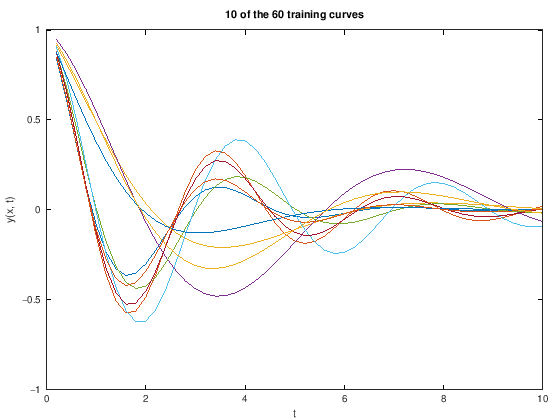

In [2]:
t = linspace(0.2, 10, 50);                         % q = 50 time steps
simulator = @(X) exp(-(0.1 + 0.5 * X(:, 2)) * t) .* cos(2 * pi * (0.5 + X(:, 1)) * t / 5);   % n x q

rand('seed', 1);
X = rand(60, 2);
Y = simulator(X);
Xt = rand(200, 2);
Yt = simulator(Xt);
printf('X: %d x %d   Y: %d x %d\n', size(X), size(Y));

figure; plot(t, Y(1:10, :)'); xlabel('t'); ylabel('y(x, t)'); title('10 of the 60 training curves');

## 3. `"pca"` output model

`"pca(0.999)"` keeps the principal components that explain 99.9 % of the variance of the centered curves, and fits
one `Kriging` per component score. The truncation residual is kept as white noise, so the predicted standard
deviation does not ignore the discarded components.

In [3]:
tic; pca = MultiOutputKriging(Y, X, 'matern5_2', 'pca(0.999)'); t_pca = toc;
disp(pca.summary());
expl = pca.pca_explained();
printf('components: %d   cumulative explained variance: %s\n', pca.nb_components(), mat2str(expl', 4));

* MultiOutputKriging, output model: pca(0.999)
  * covariance kernel: matern5_2
  * data: 60 x 2 -> 60 x 50
  * trend: constant
  * PCA components: 7, explained variance: 0.999541
    - component 0: cum. explained 0.603806, sigma2 1.80202, theta    0.5415   1.3879
    - component 1: cum. explained 0.84113, sigma2 3.74987, theta    0.4425   1.1240
    - component 2: cum. explained 0.922644, sigma2 1.74335, theta    0.3671   0.8868
    - component 3: cum. explained 0.97148, sigma2 0.43378, theta    0.2760   0.7744
    - component 4: cum. explained 0.988538, sigma2 0.238114, theta    0.2760   0.7146
    - component 5: cum. explained 0.998707, sigma2 0.171126, theta    0.2176   0.5601
    - component 6: cum. explained 0.999541, sigma2 0.0190612, theta    0.1949   0.5628



components: 7   cumulative explained variance: [0.6038 0.8411 0.9226 0.9715 0.9885 0.9987 0.9995]


In [4]:
scores = @(m, s) [sqrt(mean((m(:) - Yt(:)).^2)) / std(Yt(:)), mean(abs(m(:) - Yt(:)) <= 1.96 * s(:))];

[m_pca, s_pca] = pca.predict(Xt, true, false, false);
printf('mean, stdev: %d x %d, %d x %d\n', size(m_pca), size(s_pca));
r_pca = scores(m_pca, s_pca);
printf('pca: RMSE / sd(Y) = %.4f, coverage of the 95%% intervals = %.3f\n', r_pca);

mean, stdev: 200 x 50, 200 x 50


pca: RMSE / sd(Y) = 0.0445, coverage of the 95% intervals = 0.946


Predicted curves at three test inputs: predicted mean (solid), 95 % band (mean ± 1.96 stdev, shaded) and true
curve (dashed).

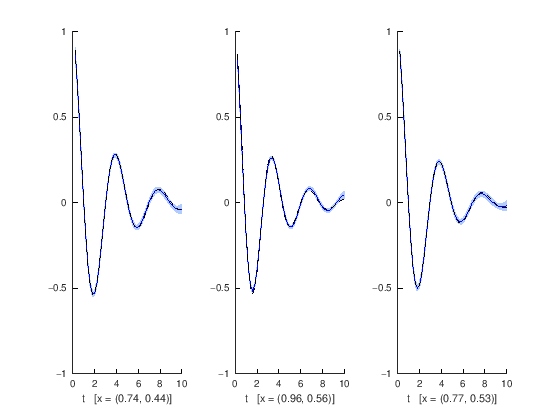

In [5]:
figure;
for i = 1:3
    subplot(1, 3, i); hold on;
    lo = m_pca(i, :) - 1.96 * s_pca(i, :); hi = m_pca(i, :) + 1.96 * s_pca(i, :);
    fill([t, fliplr(t)], [lo, fliplr(hi)], [0.7 0.8 1], 'edgecolor', 'none');   % 95% band
    plot(t, m_pca(i, :), 'b');                                                    % predicted mean
    plot(t, Yt(i, :), 'k--');                                                     % true curve
    xlabel(sprintf('t   [x = (%.2f, %.2f)]', Xt(i, 1), Xt(i, 2)));
    hold off;
end

## 4. `"shared"` output model

One θ for all 50 outputs, maximizing the summed concentrated log-likelihood: each likelihood evaluation costs
**one** Cholesky factorization for the 50 outputs. Each output keeps its own trend β_j and variance σ_j².

In [6]:
tic; shared = MultiOutputKriging(Y, X, 'matern5_2', 'shared'); t_shared = toc;
th = shared.theta();
printf('theta: %s\n', mat2str(th', 4));
[m_s, s_s] = shared.predict(Xt, true, false, false);
r_shared = scores(m_s, s_s);
printf('shared: RMSE / sd(Y) = %.4f, coverage = %.3f\n', r_shared);

theta: [0.7088 1.646]


shared: RMSE / sd(Y) = 0.0366, coverage = 0.950


## 5. Baseline: one independent `Kriging` per output

50 separate fits, each with its own θ. This remains a valid baseline: each time step gets the θ that suits it,
which can be slightly more accurate or not, depending on the design. The cost is 50 optimizations instead of one (`"shared"`) or a
handful (`"pca"`), no information shared between time steps, and no joint covariance between outputs.

In [7]:
tic;
models = cell(1, size(Y, 2));
for j = 1:size(Y, 2)
    models{j} = Kriging(Y(:, j), X, 'matern5_2');
end
t_indep = toc;
m_i = zeros(size(Yt)); s_i = zeros(size(Yt));
for j = 1:size(Y, 2)
    [m_i(:, j), s_i(:, j)] = models{j}.predict(Xt, true, false, false);
end
r_indep = scores(m_i, s_i);
printf('independent: RMSE / sd(Y) = %.4f, coverage = %.3f\n', r_indep);

independent: RMSE / sd(Y) = 0.0396, coverage = 0.961


## 6. `"separable"` output model: joint covariance

`"separable"` estimates a free output covariance Σ (here between 3 close time steps, $t \approx 4.2, 4.6, 5.0$,
which are strongly correlated). Its predictive
covariance couples the outputs, $\mathrm{Cov}(\mathrm{vec}\,Y_n) = \Sigma \otimes C_x$, so it gives a consistent
uncertainty for any combination of outputs, e.g. the difference $Y(t_1) - Y(t_2)$. `"shared"` treats the outputs
as independent and gets that variance wrong when they are correlated.

`"separable"` needs $n - p \ge q$ and refuses nearly linearly dependent outputs (such as the 50 finely sampled time
steps): use `"pca"` or `"separable(<kernel>)"` for whole curves.

In [8]:
cols = [21, 23, 25];                               % t ~ 4.2, 4.6, 5.0
printf('t: %s\n', mat2str(t(cols), 3));
sep = MultiOutputKriging(Y(:, cols), X, 'matern5_2', 'separable');
S = sep.output_cov();
d = sqrt(diag(S));
disp(round(1000 * S ./ (d * d')) / 1000);

t: [4.2 4.6 5]


   1.0000   0.8520   0.3790
   0.8520   1.0000   0.8010
   0.3790   0.8010   1.0000


Check on the test runs: compare the standard deviation of the standardized errors (error / predicted stdev) of
$Y(t_1)$ alone and of the difference $Y(t_1) - Y(t_2)$. Both models are conservative on $Y(t_1)$ alone (smooth
kernel), with a standard deviation below 1. `"separable"` stays of the same order for the difference;
`"shared"` ignores the correlation between the outputs, so its predicted variance of the difference is many times
too large and the standardized errors are much smaller than 1.

In [9]:
function c = calibration(model, Xt, Yt, cols)
    % sd of the standardized errors of Y(t1) alone and of Y(t1) - Y(t2), from the joint covariance
    [m, s, C] = model.predict(Xt, true, true, false);
    M = size(Xt, 1); i = (1:M)';
    v = C(sub2ind(size(C), i, i)) + C(sub2ind(size(C), M + i, M + i)) - 2 * C(sub2ind(size(C), i, M + i));
    err1 = m(:, 1) - Yt(:, cols(1));
    err = (m(:, 1) - m(:, 2)) - (Yt(:, cols(1)) - Yt(:, cols(2)));
    c = [std(err1 ./ s(:, 1)), std(err ./ sqrt(v))];
end

sh3 = MultiOutputKriging(Y(:, cols), X, 'matern5_2', 'shared');
printf('sd of the standardized errors:     Y(t1)   Y(t1) - Y(t2)\n');
printf('  separable                       %5.2f   %5.2f\n', calibration(sep, Xt, Yt, cols));
printf('  shared                          %5.2f   %5.2f\n', calibration(sh3, Xt, Yt, cols));

[Cx, Sigma] = sep.predictCovFactors(Xt(1:5, :));
printf('predictCovFactors: %d x %d, %d x %d\n', size(Cx), size(Sigma));

sd of the standardized errors:     Y(t1)   Y(t1) - Y(t2)


  separable                        0.77    0.85


  shared                           0.73    0.32


predictCovFactors: 5 x 5, 3 x 3


## 7. `"separable(matern5_2)"`: a kernel over the time steps

With the time steps as output coordinates, Σ can be a kernel over them: $\Sigma = \sigma^2 R_t(\phi)$, here a
Matérn 5/2 correlation in $t$ with one range φ, estimated with θ by maximum likelihood. Two parameters replace the
$q(q+1)/2 = 1275$ entries of a free Σ, so the 50 finely sampled outputs are not a problem (the free Σ of
`"separable"` is singular there). The predictive mean is that of `"shared"` at the same θ; the joint covariance
couples all the time steps.

`normalize=true` gives each time step its own scale, which matters here since the curves decay along $t$.

In [10]:
tic;
sk = MultiOutputKriging('matern5_2', 'separable(matern5_2)');
sk.set_output_coordinates(t');
sk.fit(Y, X, 'constant', true);
t_sk = toc;
printf('theta: %s  phi (range in t): %s\n', mat2str(sk.theta()', 3), mat2str(sk.output_theta(), 3));
[m_k, s_k] = sk.predict(Xt, true, false, false);
r_sk = scores(m_k, s_k);
printf('separable(matern5_2): RMSE / sd(Y) = %.4f, coverage = %.3f\n', r_sk);
S = sk.output_cov();
printf('output correlation of t = 4.2 with t = 4.6, 5.0: %s\n', mat2str(S(21, [23, 25]) / S(21, 21), 3));

theta: [0.294 0.763]  phi (range in t): 0.824


separable(matern5_2): RMSE / sd(Y) = 0.0390, coverage = 0.959


output correlation of t = 4.2 with t = 4.6, 5.0: [0.837 0.541]


Over all outputs, the standardized errors (error / predicted stdev) have a standard deviation somewhat below 1
(about 0.6 to 1 depending on the design): the model is a little conservative. Without `normalize=true` it is far
more so (about 0.07 on this design, coverage 1). The reason is that $R_t$ is **stationary**: one variance and one
correlation structure for the whole time axis, while these curves start from 1 for every input and decay along $t$.
Scaling each time step absorbs the decay; what remains is a correlation in $t$ that depends on $x$ (the frequency).
`"pca"` adapts to such curves without any assumption on $t$; `"separable(<kernel>)"` suits outputs whose
correlation depends mainly on the distance in $t$ (spatial fields, stationary time series), and gives a joint
covariance over all of them.

In [11]:
z_k = (m_k - Yt) ./ s_k; z_p = (m_pca - Yt) ./ s_pca;
printf('sd of the standardized errors (all outputs): separable(matern5_2) %.2f, pca %.2f\n', std(z_k(:)), std(z_p(:)));

sd of the standardized errors (all outputs): separable(matern5_2) 0.99, pca 1.14


## 8. `update` and `update_simulate`

`simulate(..., will_update=true)` draws joint trajectories of all outputs and keeps what `update_simulate` needs.
When 5 new runs arrive, `update_simulate` conditions the **same** trajectories on them, without refitting. Its
empirical mean should match the prediction of the model updated with `update(..., refit=false)`.

simulate: 4 x 50 x 2000 (m x q x nsim)


max |empirical mean - updated mean| / max stdev: 0.0502


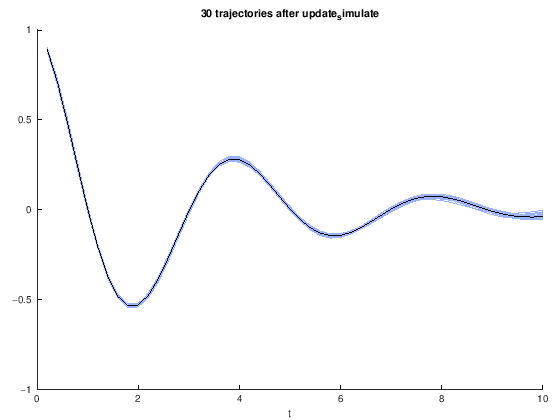

In [12]:
xs = Xt(1:4, :);                                   % where the trajectories are drawn
Xu = Xt(101:105, :); Yu = Yt(101:105, :);          % 5 new runs
sims = pca.simulate(int32(2000), int32(7), xs, true);
printf('simulate: %d x %d x %d (m x q x nsim)\n', size(sims));
sims_u = pca.update_simulate(Yu, Xu);

pca.update(Yu, Xu, false);
[m_u, s_u] = pca.predict(xs, true, false, false);
emp = mean(sims_u, 3);
printf('max |empirical mean - updated mean| / max stdev: %.4f\n', max(abs(emp(:) - m_u(:))) / max(s_u(:)));

figure; hold on;
plot(t, squeeze(sims_u(1, :, 1:30)), 'color', [0.6 0.7 1]);
plot(t, m_u(1, :), 'k', 'linewidth', 2);
title('30 trajectories after update\_simulate'); xlabel('t'); hold off;

## 9. `save` and `load`

`save` writes the configuration, the data and the fitted state to a JSON file; `load` restores it exactly
(the generic `load` of each binding recognizes the file). The state of the last `simulate` is not saved: simulate
again before `update_simulate`.

In [13]:
f = [tempname(), '.json'];
pca.save(f);                                       % the updated pca model of section 8
loaded = load_kriging(f);                          % or MultiOutputKriging.load(f)
printf('%s %s %d components\n', class(loaded), loaded.output_model(), loaded.nb_components());
m1 = pca.predict(Xt, false, false, false); m2 = loaded.predict(Xt, false, false, false);
printf('max |difference| of the predicted means: %g\n', max(abs(m1(:) - m2(:))));

MultiOutputKriging pca(0.999) 7 components


max |difference| of the predicted means: 0


## 10. Summary

| Output model | Use it for | Hyperparameters |
|---|---|---|
| `"pca"` | many correlated outputs: curves, fields, q ≫ n possible | one Kriging per principal score |
| `"shared"` | outputs of similar regularity, marginal predictions | one θ, (β_j, σ_j²) per output |
| `"separable"` | a few correlated outputs, joint covariance or joint simulations | one θ, β_j per output, free Σ |
| `"separable(<kernel>)"` | outputs with coordinates and a stationary correlation along them, q ≫ n possible | one θ, β_j per output, σ², φ |

All four share the kernels, trends, `normalize` and optimizers of `Kriging`. Current limitations: isotopic design
only (no missing value in `Y`), no noise/nugget.

In [14]:
printf('%-12s %10s %9s %13s\n', 'model', 'RMSE/sd(Y)', 'coverage', 'fit time (s)');
printf('%-12s %10.4f %9.3f %13.2f\n', 'pca', r_pca, t_pca);
printf('%-12s %10.4f %9.3f %13.2f\n', 'shared', r_shared, t_shared);
printf('%-12s %10.4f %9.3f %13.2f\n', 'independent', r_indep, t_indep);
printf('%-12s %10.4f %9.3f %13.2f\n', 'sep(matern)', r_sk, t_sk);

model        RMSE/sd(Y)  coverage  fit time (s)


pca              0.0445     0.946          0.04


shared           0.0366     0.950          0.00


independent      0.0396     0.961          0.21


sep(matern)      0.0390     0.959          0.02
